In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)


from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, auc,
    average_precision_score,
)


In [2]:
# --- your paths (same as notebook) ---
OUT = Path("/Users/921623492/Abdoul Thesis/results/snp/2025-12-24/snp_output")
TRAIN_NAME = "SNP_merged_train"

CV_DIR = OUT / TRAIN_NAME / "CVDatasets"
MODEL_DIR = OUT / TRAIN_NAME / "models" / "pickledModels"


In [ ]:
original_test_data = pd.read_csv("/Users/921623492/Abdoul Thesis/results/snp/2025-12-24/snp_output")
test_data = pd.read_csv(OUT / "logs" / "replication" / "SNP_merged_test" / "SNP_merged_test_Processed.csv")


In [ ]:
original_test_data['label'] = original_test_data['label'].astype(str).str.strip().map({"R": 0, "S": 1})


In [ ]:
original_test_data.head()


,sample_id,SNP_0,SNP_1,SNP_2,SNP_3,SNP_4,SNP_5,SNP_6,SNP_7,SNP_8,...,SNP_56708,SNP_56709,SNP_56710,SNP_56711,SNP_56712,SNP_56713,SNP_56714,SNP_56715,SNP_56716,label
0,ERR1218582,0,0,0,1,1,0,1,1,1,...,0,1,1,1,0,1,1,0,2,0
1,ERR1218605,0,0,0,1,0,0,1,0,0,...,0,0,1,1,0,1,1,1,1,0
2,ERR1218607,0,0,0,1,1,0,1,1,1,...,0,1,1,1,0,1,1,0,2,0
3,ERR1218623,0,0,0,1,1,0,1,1,1,...,0,1,1,1,0,1,1,0,2,0
4,ERR1218646,0,1,1,1,0,0,1,0,0,...,0,0,1,1,0,1,1,1,1,0


In [ ]:
test_data.head()


,sample_id,SNP_0,SNP_1,SNP_2,SNP_3,SNP_4,SNP_5,SNP_6,SNP_7,SNP_8,...,SNP_56699_0,SNP_56699_1,SNP_56699_2,SNP_56700_0,SNP_56700_1,SNP_56700_2,SNP_56700_3,SNP_56716_0,SNP_56716_1,SNP_56716_2
0,ERR1218582,0,0,0,1,1,0,1,1,1,...,False,True,False,False,True,False,0,0,0,0
1,ERR1218605,0,0,0,1,0,0,1,0,0,...,False,False,True,False,False,True,0,0,0,0
2,ERR1218607,0,0,0,1,1,0,1,1,1,...,False,True,False,False,True,False,0,0,0,0
3,ERR1218623,0,0,0,1,1,0,1,1,1,...,False,True,False,False,True,False,0,0,0,0
4,ERR1218646,0,1,1,1,0,0,1,0,0,...,False,True,False,False,True,False,0,0,0,0


In [ ]:
labels = original_test_data[["sample_id", "label"]].copy()
labels = labels.rename(columns={"label": "label_raw"})


In [ ]:
test_encoded = test_data.merge(labels, on="sample_id", how="left", validate="one_to_one")
print("Columns containing label:", [c for c in test_encoded.columns if "label" in c.lower()])
print("Missing labels:", test_encoded["label"].isna().sum())


Columns containing label: ['label', 'label_raw']
Missing labels: 0


In [ ]:
test_encoded.head()


,sample_id,SNP_0,SNP_1,SNP_2,SNP_3,SNP_4,SNP_5,SNP_6,SNP_7,SNP_8,...,SNP_56699_1,SNP_56699_2,SNP_56700_0,SNP_56700_1,SNP_56700_2,SNP_56700_3,SNP_56716_0,SNP_56716_1,SNP_56716_2,label_raw
0,ERR1218582,0,0,0,1,1,0,1,1,1,...,True,False,False,True,False,0,0,0,0,0
1,ERR1218605,0,0,0,1,0,0,1,0,0,...,False,True,False,False,True,0,0,0,0,0
2,ERR1218607,0,0,0,1,1,0,1,1,1,...,True,False,False,True,False,0,0,0,0,0
3,ERR1218623,0,0,0,1,1,0,1,1,1,...,True,False,False,True,False,0,0,0,0,0
4,ERR1218646,0,1,1,1,0,0,1,0,0,...,True,False,False,True,False,0,0,0,0,0


In [ ]:

# Choose label column (in your notebook you used label_raw; use whatever exists)
if "label_raw" in test_encoded.columns:
    label_col = "label_raw"
elif "label" in test_encoded.columns:
    label_col = "label"
else:
    raise ValueError("No label column found (expected 'label' or 'label_raw').")


In [ ]:
def build_test_matrix_for_fold(df: pd.DataFrame, cv_train_csv: Path, label_col: str):
    cv_cols = pd.read_csv(cv_train_csv, nrows=0).columns.tolist()
    feat_cols = [c for c in cv_cols if c not in ["label", "sample_id"]]

    if "sample_id" not in df.columns:
        raise ValueError("`sample_id` missing from test dataset.")
    if label_col not in df.columns:
        raise ValueError(f"`{label_col}` missing from test dataset.")

    # STRICT: do not auto-create missing features
    missing = [c for c in feat_cols if c not in df.columns]
    if missing:
        raise ValueError(
            f"Test dataset is missing {len(missing)} features required by fold {cv_train_csv.name}. "
            f"Example missing: {missing[:20]}"
        )

    X_df = df[feat_cols].copy()
    X_df = X_df.replace({True: 1, False: 0}).fillna(0)

    X = X_df.to_numpy()
    y = df[label_col].astype(int).to_numpy()
    ids = df["sample_id"].astype(str).to_numpy()

    return X, y, ids, feat_cols


In [ ]:
y_all = test_encoded[label_col].astype(int).to_numpy()
pos_rate = (y_all == 1).mean()   # pipeline no-skill line for replication PRC

model_paths = sorted(MODEL_DIR.glob("*.pickle"))

curves = {}  # curves[algo][fold] = dict with roc/pr arrays + scalars

for model_path in model_paths:
    algo, fold_str = model_path.stem.rsplit("_", 1)
    fold = int(fold_str)

    cv_train_csv = CV_DIR / f"{TRAIN_NAME}_CV_{fold}_Train.csv"
    X, y, *_ = build_test_matrix_for_fold(test_encoded, cv_train_csv, label_col=label_col)

    model = joblib.load(model_path)
    prob = model.predict_proba(X)[:, 1]

    # ROC
    fpr, tpr, _ = roc_curve(y, prob)
    roc_auc = roc_auc_score(y, prob)

    # PRC (IMPORTANT: reverse arrays like STREAMLINE does so recall increases 0->1 for np.interp)
    prec, recall, _ = precision_recall_curve(y, prob)
    prec = prec[::-1]
    recall = recall[::-1]
    pr_auc = auc(recall, prec)
    aps = average_precision_score(y, prob)

    curves.setdefault(algo, {})[fold] = {
        "fpr": fpr, "tpr": tpr, "roc_auc": roc_auc,
        "prec": prec, "recall": recall, "pr_auc": pr_auc, "aps": aps,
    }


/tmp/ipykernel_1909174/4270562438.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_df = X_df.replace({True: 1, False: 0}).fillna(0)
/tmp/ipykernel_1909174/4270562438.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_df = X_df.replace({True: 1, False: 0}).fillna(0)
/tmp/ipykernel_1909174/4270562438.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, s

In [ ]:
def plot_algo_roc(algo: str, algo_curves: dict, color=None, save_path=None):
    mean_fpr = np.linspace(0, 1, 100)

    folds = sorted(algo_curves.keys())
    tprs, aucs = [], []

    plt.rcParams["figure.figsize"] = (6, 6)

    # Individual folds
    for i, fold in enumerate(folds):
        fpr = algo_curves[fold]["fpr"]
        tpr = algo_curves[fold]["tpr"]
        roc_auc = algo_curves[fold]["roc_auc"]

        plt.plot(fpr, tpr, lw=1, alpha=0.3, label=f"ROC fold {fold} (AUC = {roc_auc:.3f})")

        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc)

    # No-skill line
    plt.plot([0, 1], [0, 1], linestyle="--", lw=2, color="black", label="No-Skill", alpha=0.8)

    # Mean + std shading
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = float(np.mean(aucs))
    std_auc = float(np.std(aucs))

    if color is None:
        color = "C0"

    plt.plot(
        mean_fpr, mean_tpr, color=color,
        label=rf"Mean ROC (AUC = {mean_auc:.3f} $\pm$ {std_auc:.3f})",
        lw=2, alpha=0.8
    )

    std_tpr = np.std(tprs, axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
    plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color="grey", alpha=0.2, label=r"$\pm$ 1 std. dev.")

    plt.xlim([-0.05, 1.05]); plt.ylim([-0.05, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(algo)
    plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1))

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        plt.close("all")
    else:
        plt.show()

    return {"mean_fpr": mean_fpr, "mean_tpr": mean_tpr, "mean_auc": mean_auc}


In [ ]:

def plot_algo_prc(algo: str, algo_curves: dict, pos_rate: float, color=None, save_path=None):
    mean_recall = np.linspace(0, 1, 100)

    folds = sorted(algo_curves.keys())
    precs, praucs, aps_list = [], [], []

    plt.rcParams["figure.figsize"] = (6, 6)

    # Individual folds
    for fold in folds:
        recall = algo_curves[fold]["recall"]
        prec = algo_curves[fold]["prec"]
        pr_auc = algo_curves[fold]["pr_auc"]

        plt.plot(recall, prec, lw=1, alpha=0.3, label=f"PRC fold {fold} (AUC = {pr_auc:.3f})")

        interp_prec = np.interp(mean_recall, recall, prec)
        precs.append(interp_prec)
        praucs.append(pr_auc)
        aps_list.append(algo_curves[fold]["aps"])

    # No-skill line (replication mode): fraction of positives in your dataset
    plt.plot([0, 1], [pos_rate, pos_rate], color="black", linestyle="--", label="No-Skill", alpha=0.8)

    # Mean + std shading
    mean_prec = np.mean(precs, axis=0)
    mean_pr_auc = float(np.mean(praucs))
    std_pr_auc = float(np.std(praucs))

    if color is None:
        color = "C0"

    plt.plot(
        mean_recall, mean_prec, color=color,
        label=rf"Mean PRC (AUC = {mean_pr_auc:.3f} $\pm$ {std_pr_auc:.3f})",
        lw=2, alpha=0.8
    )

    std_prec = np.std(precs, axis=0)
    precs_upper = np.minimum(mean_prec + std_prec, 1)
    precs_lower = np.maximum(mean_prec - std_prec, 0)
    plt.fill_between(mean_recall, precs_lower, precs_upper, color="grey", alpha=0.2, label=r"$\pm$ 1 std. dev.")

    plt.xlim([-0.05, 1.05]); plt.ylim([-0.05, 1.05])
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision (PPV)")
    plt.title(algo)
    plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1))

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        plt.close("all")
    else:
        plt.show()

    return {
        "mean_recall": mean_recall,
        "mean_prec": mean_prec,
        "mean_pr_auc": mean_pr_auc,
        "mean_aps": float(np.mean(aps_list)),
    }


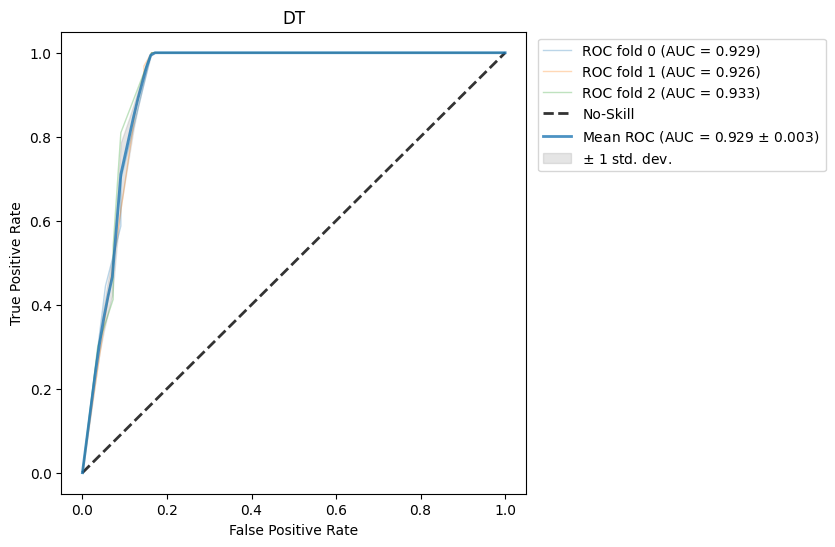

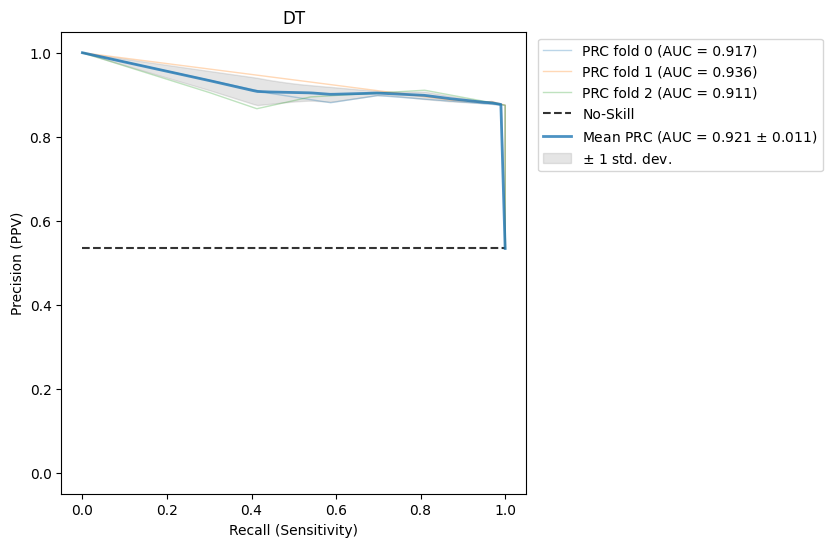

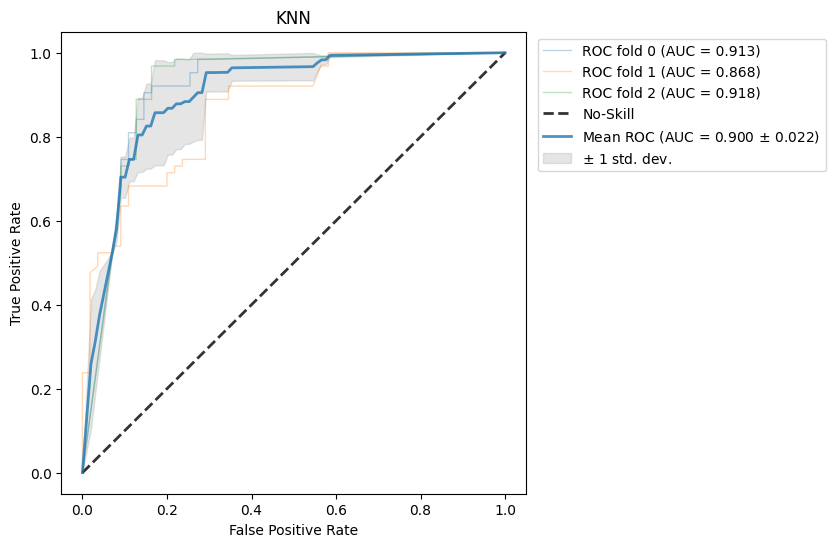

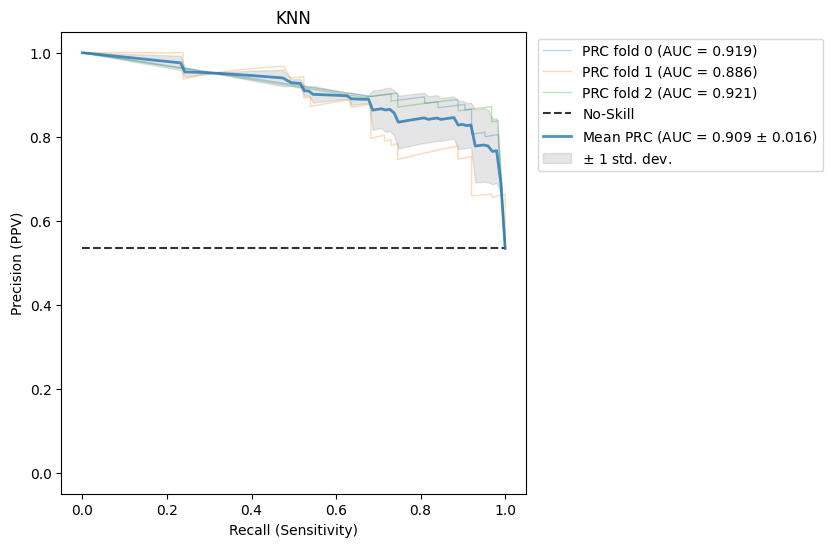

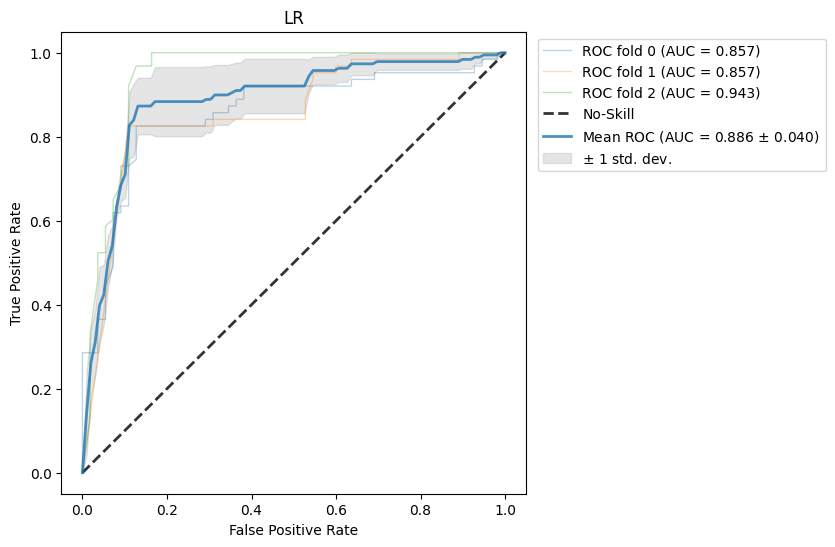

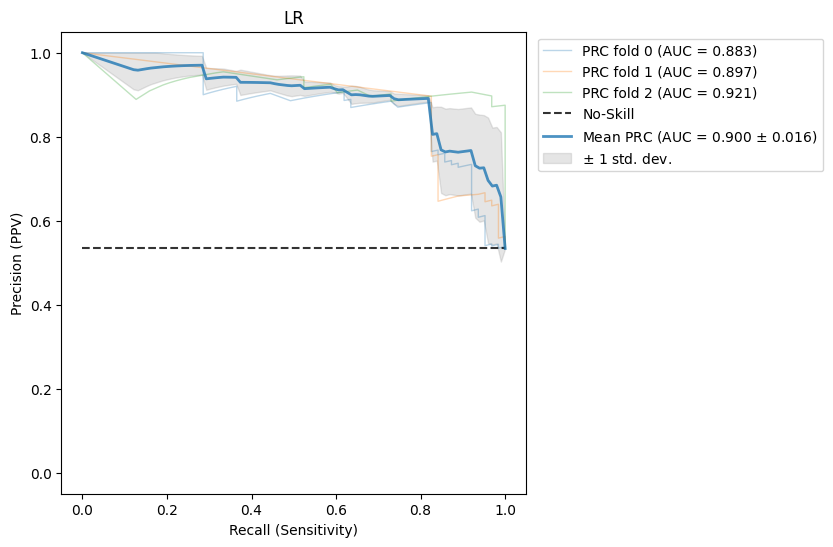

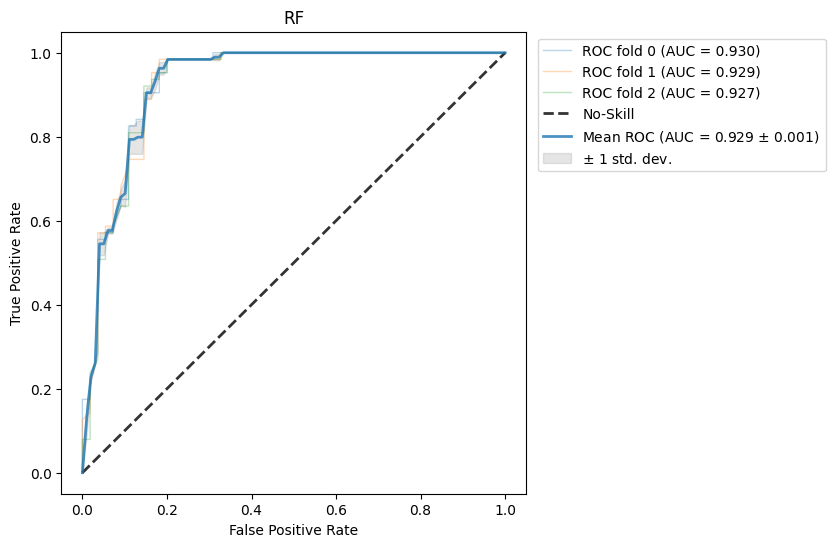

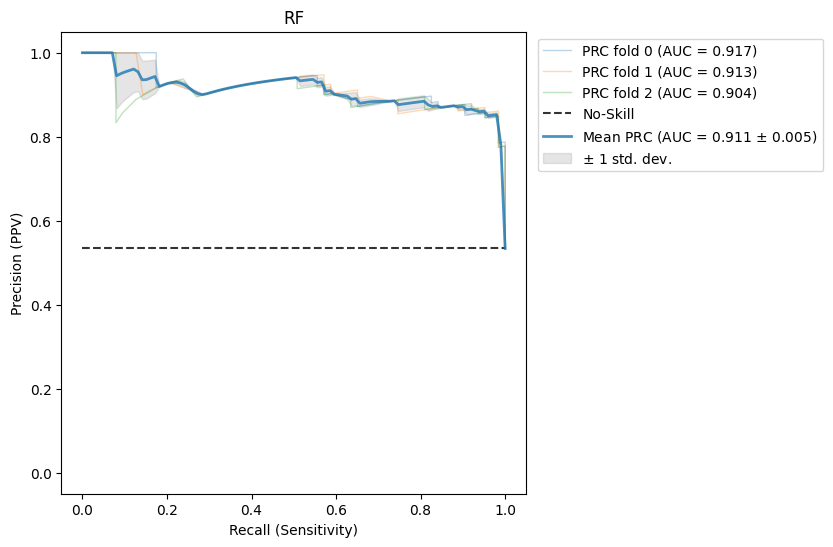

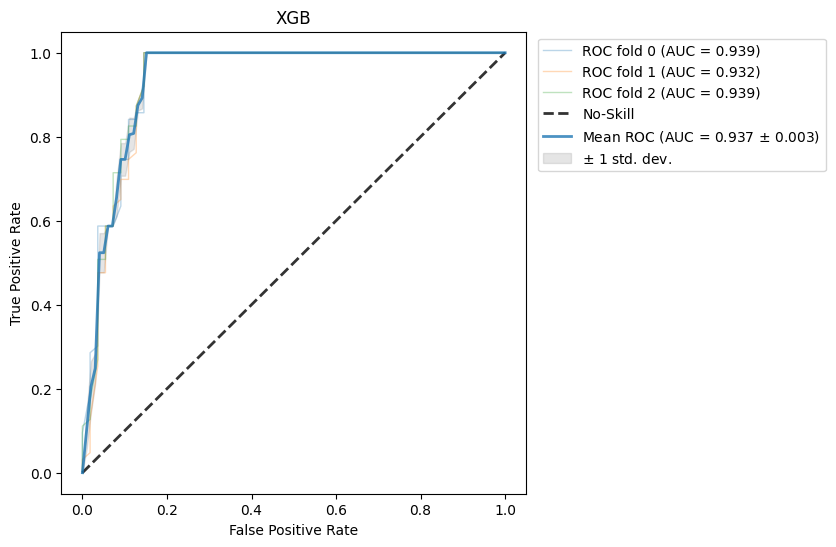

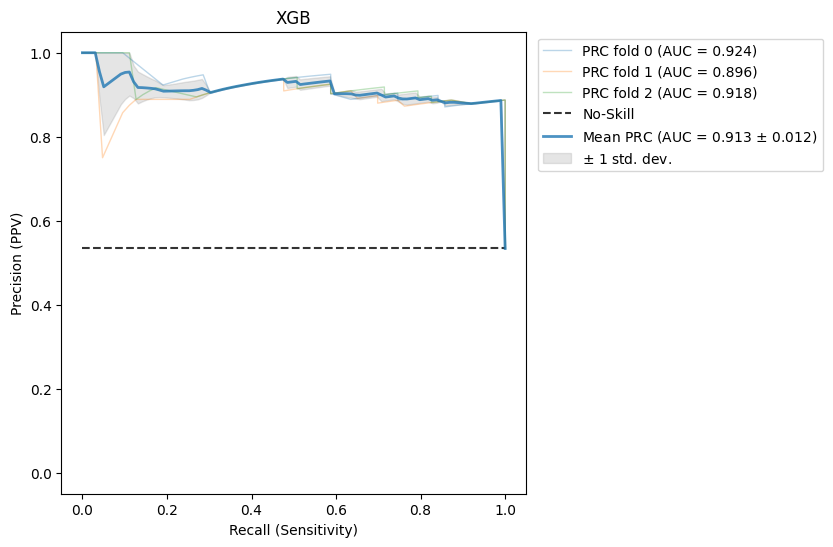

In [ ]:
summary = {}  # store mean curves for summary plots

for algo in sorted(curves.keys()):
    roc_out = plot_algo_roc(algo, curves[algo], save_path=None)  # or save_path=".../DT_ROC.png"
    prc_out = plot_algo_prc(algo, curves[algo], pos_rate=pos_rate, save_path=None)  # or ".../DT_PRC.png"

    summary[algo] = {**roc_out, **prc_out}


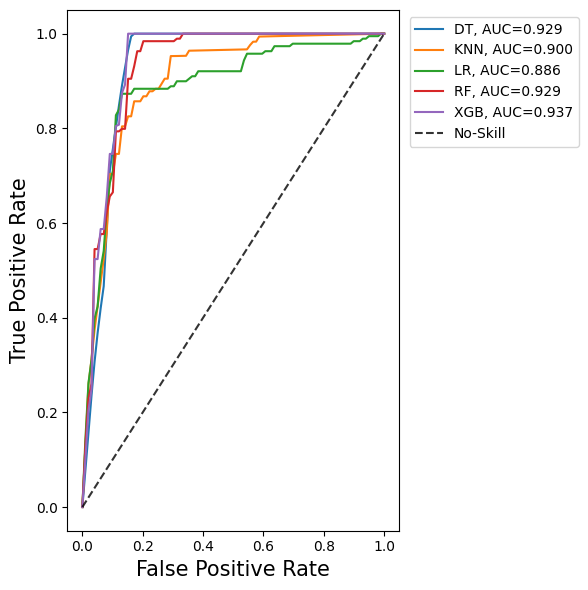

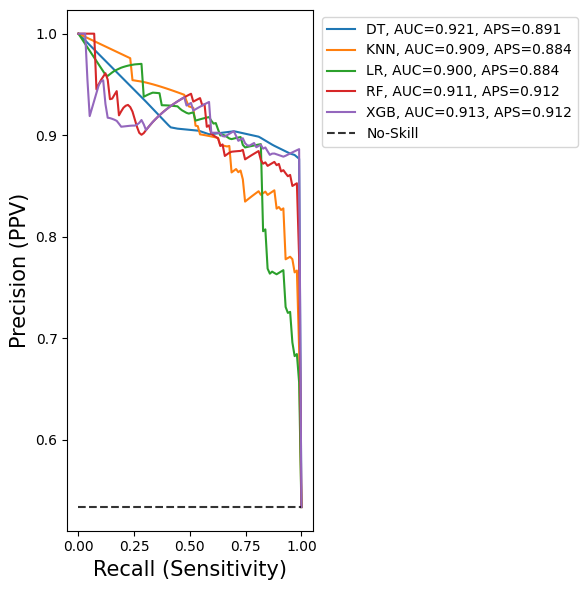

In [ ]:
# Summary ROC
plt.rcParams["figure.figsize"] = (6, 6)
for algo in summary:
    plt.plot(summary[algo]["mean_fpr"], summary[algo]["mean_tpr"], label=f"{algo}, AUC={summary[algo]['mean_auc']:.3f}")
plt.plot([0, 1], [0, 1], color="black", linestyle="--", label="No-Skill", alpha=0.8)
plt.xlabel("False Positive Rate", fontsize=15)
plt.ylabel("True Positive Rate", fontsize=15)
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()  # or plt.savefig("Summary_ROC.png", bbox_inches="tight"); plt.close("all")


# Summary PRC
plt.rcParams["figure.figsize"] = (6, 6)
for algo in summary:
    plt.plot(
        summary[algo]["mean_recall"], summary[algo]["mean_prec"],
        label=f"{algo}, AUC={summary[algo]['mean_pr_auc']:.3f}, APS={summary[algo]['mean_aps']:.3f}"
    )
plt.plot([0, 1], [pos_rate, pos_rate], color="black", linestyle="--", label="No-Skill", alpha=0.8)
plt.xlabel("Recall (Sensitivity)", fontsize=15)
plt.ylabel("Precision (PPV)", fontsize=15)
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()  # or plt.savefig("Summary_PRC.png", bbox_inches="tight"); plt.close("all")


In [ ]:
pickled = "01_experiment.ipynb/Users/921623492/Ecoli_Project/ML/Final_ML_02/STREAMLINE/Abdoul_Output/Abdoul_thesis/SNP_merged_train/exploratory/one_hot_feature.pickle"


In [ ]:
import pickle

with open("/Users/921623492/Ecoli_Project/ML/Final_ML_02/STREAMLINE/Abdoul_Output/Abdoul_thesis/SNP_merged_train/exploratory/one_hot_feature.pickle", "rb") as f:
    one_hot_features = pickle.load(f)

type(one_hot_features)


list

In [ ]:
one_hot_features[:100]


['SNP_29_0',
 'SNP_29_1',
 'SNP_29_2',
 'SNP_42_0',
 'SNP_42_1',
 'SNP_42_2',
 'SNP_53_0',
 'SNP_53_1',
 'SNP_53_2',
 'SNP_67_0',
 'SNP_67_1',
 'SNP_67_2',
 'SNP_73_0',
 'SNP_73_1',
 'SNP_73_2',
 'SNP_84_0',
 'SNP_84_1',
 'SNP_84_2',
 'SNP_89_0',
 'SNP_89_1',
 'SNP_89_2',
 'SNP_90_0',
 'SNP_90_1',
 'SNP_90_2',
 'SNP_91_0',
 'SNP_91_1',
 'SNP_91_2',
 'SNP_94_0',
 'SNP_94_1',
 'SNP_94_2',
 'SNP_96_0',
 'SNP_96_1',
 'SNP_96_2',
 'SNP_103_0',
 'SNP_103_1',
 'SNP_103_2',
 'SNP_137_0',
 'SNP_137_1',
 'SNP_137_2',
 'SNP_151_0',
 'SNP_151_1',
 'SNP_151_2',
 'SNP_165_0',
 'SNP_165_1',
 'SNP_165_2',
 'SNP_167_0',
 'SNP_167_1',
 'SNP_167_2',
 'SNP_170_0',
 'SNP_170_1',
 'SNP_170_2',
 'SNP_211_0',
 'SNP_211_1',
 'SNP_211_2',
 'SNP_213_0',
 'SNP_213_1',
 'SNP_213_2',
 'SNP_217_0',
 'SNP_217_1',
 'SNP_217_2',
 'SNP_219_0',
 'SNP_219_1',
 'SNP_219_2',
 'SNP_251_0',
 'SNP_251_1',
 'SNP_251_2',
 'SNP_255_0',
 'SNP_255_1',
 'SNP_255_2',
 'SNP_260_0',
 'SNP_260_1',
 'SNP_260_2',
 'SNP_263_0',
 'SNP_263_1